In [122]:
import geopandas as gpd
import pandas as pd
import json

# # 1. Load your BWA data
# with open('merged_json_output/merged_output.json', 'r') as f:
#     bwa_data = pd.DataFrame(json.load(f))


# 1. Load your BWA data
bwa_data = pd.read_excel("final_for_geospatial.xlsx")






In [128]:
bwa_data.head(2)

# print(bwa_data['city'].value_counts())

,url_issued,PWS ID,PWS_clean,PWS Name,issued_date_issued,rescinded_date_rescinded,Population Served Count,city_cleaned_issued,city_norm,Cities Served,city,Counties Served,county
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-02-28,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-03-05,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County


In [129]:
print(bwa_data.columns)

Index(['url_issued', 'PWS ID', 'PWS_clean', 'PWS Name', 'issued_date_issued',
       'rescinded_date_rescinded', 'Population Served Count',
       'city_cleaned_issued', 'city_norm', 'Cities Served', 'city',
       'Counties Served', 'county'],
      dtype='object')


In [124]:
# Geting Kansas county boundaries
# Download from: https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/
counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
ks_counties = counties[counties['STATEFP'] == '20'].copy()  # Kansas FIPS = 20
# counties.head()



In [132]:
# Clean county names in bwd dataset and ks_counties for matching
# bwa_data['county_clean'] = bwa_data['county'].str.replace(' County', '').str.strip().str.upper()

bwa_data['county_clean'] = bwa_data['Counties Served'].str.split(",").str[0].str.strip().str.upper()

ks_counties['NAME'] = ks_counties['NAME'].str.upper()
# bwa_data.head()
# ks_counties

### Getting polygon geometry based on county only

In [133]:
# Merge both the datasets on county name to get geometries
bwa_geo = bwa_data.merge(
    ks_counties[['NAME', 'GEOID', 'geometry']], 
    left_on='county_clean', 
    right_on='NAME', 
    how='left'
)

bwa_geo.head()

,url_issued,PWS ID,PWS_clean,PWS Name,issued_date_issued,rescinded_date_rescinded,Population Served Count,city_cleaned_issued,city_norm,Cities Served,city,Counties Served,county,county_clean,NAME,GEOID,geometry
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-02-28,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County,OSAGE,OSAGE,20139,"POLYGON ((-95.6 38.434, -95.601 38.434, -95.60..."
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-03-05,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County,OSAGE,OSAGE,20139,"POLYGON ((-95.6 38.434, -95.601 38.434, -95.60..."
2,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2007304,fall river,"FALL RIVER, CITY OF",2024-03-22,2024-03-27,129,fall river,fall river,FALL RIVER,Fall River,"Greenwood, Greenwood",Greenwood County,GREENWOOD,GREENWOOD,20073,"POLYGON ((-96.358 38.086, -96.358 38.088, -96...."
3,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2011509,peabody,"PEABODY, CITY OF",2024-03-26,2024-03-28,932,peabody,peabody,PEABODY,Peabody,"Marion, Marion",Marion County,MARION,MARION,20115,"POLYGON ((-97.151 38.61, -97.147 38.61, -97.14..."
4,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2005304,kanopolis,"KANOPOLIS, CITY OF",2024-03-27,2024-03-30,453,kanopolis,kanopolis,KANOPOLIS,Kanopolis,"Ellsworth, Ellsworth",Ellsworth County,ELLSWORTH,ELLSWORTH,20053,"POLYGON ((-98.035 38.522, -98.036 38.522, -98...."


### Geocoding based on city only

In [134]:
from geopy.geocoders import Nominatim
from shapely.geometry import Point
import time

# Initializing geocoder
geolocator = Nominatim(user_agent="kansas_bwa_analysis")

def geocode_city(city, county):
    """Geocode Kansas city"""
    try:
        location = geolocator.geocode(f"{city}, {county}, Kansas, USA")
        if location:
            return location.latitude, location.longitude
        else:
            return None, None
    except:
        return None, None

# Apply geocoding (with delay to respect API limits)
bwa_data['lat'] = None
bwa_data['lon'] = None

for idx, row in bwa_data.iterrows():
    lat, lon = geocode_city(row['Cities Served'], row['county_clean'])
    bwa_data.at[idx, 'lat'] = lat
    bwa_data.at[idx, 'lon'] = lon
    time.sleep(1)  # 1 second delay between requests
    
    if idx % 50 == 0:
        print(f"Geocoded {idx}/{len(bwa_data)}")

# Check results
print(f"\nSuccessfully geocoded: {bwa_data['lat'].notna().sum()}/{len(bwa_data)}")
print(f"\nFailed geocoding:")
print(bwa_data[bwa_data['lat'].isna()][['Cities Served', 'county_clean']].drop_duplicates())

Geocoded 0/267
Geocoded 50/267
Geocoded 100/267
Geocoded 150/267
Geocoded 200/267
Geocoded 250/267

Successfully geocoded: 266/267

Failed geocoding:
    Cities Served county_clean
219        WAMEGO    WABAUNSEE


In [135]:
bwa_data

,url_issued,PWS ID,PWS_clean,PWS Name,issued_date_issued,rescinded_date_rescinded,Population Served Count,city_cleaned_issued,city_norm,Cities Served,city,Counties Served,county,county_clean,lat,lon
0,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-02-28,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County,OSAGE,38.579733,-95.526926
1,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2013913,quenemo,"QUENEMO, CITY OF",2024-03-05,2024-03-15,287,quenemo,quenemo,QUENEMO,Quenemo,"Osage, Osage",Osage County,OSAGE,38.579733,-95.526926
2,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2007304,fall river,"FALL RIVER, CITY OF",2024-03-22,2024-03-27,129,fall river,fall river,FALL RIVER,Fall River,"Greenwood, Greenwood",Greenwood County,GREENWOOD,37.607817,-96.028043
3,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2011509,peabody,"PEABODY, CITY OF",2024-03-26,2024-03-28,932,peabody,peabody,PEABODY,Peabody,"Marion, Marion",Marion County,MARION,38.16946,-97.106696
4,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2005304,kanopolis,"KANOPOLIS, CITY OF",2024-03-27,2024-03-30,453,kanopolis,kanopolis,KANOPOLIS,Kanopolis,"Ellsworth, Ellsworth",Ellsworth County,ELLSWORTH,38.71112,-98.157277
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2016102,tuttle cc mobile home park,"TUTTLE CC MOBILE HOME PARK, LLC",2025-11-25,2025-12-04,50,"tuttle cc mhp, llc",tuttle cc mobile home park llc,MANHATTAN,"Tuttle CC Mobile Home Park, LLC","Riley, Riley",Riley County,RILEY,39.183608,-96.571669
263,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2005101,sunset valley mhp hays ks,"SUNSET VALLEY MHP HAYS KS, LLC",2025-12-03,2025-12-06,60,"sunset valley mhp, hays, ks",sunset valley mobile home park hays ks,HAYS,"Sunset Valley MHP, Hays, KS","Ellis, Ellis",Ellis County,ELLIS,38.870998,-99.331153
264,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2014923,neighbors of walnut grove,"NEIGHBORS OF WALNUT GROVE, LLC",2023-07-12,2023-07-20,256,"neighbors of walnut grove, llc",neighbors of walnut grove llc,MANHATTAN,"Neighbors of Walnut Grove, LLC","Pottawatomie, Pottawatomie",Pottawatomie County,POTTAWATOMIE,39.184728,-96.556993
265,https://www.kdhe.ks.gov/m/newsflash/Home/Detai...,KS2016118,colonial gardens mobile home ct,COLONIAL GARDENS MOBILE HOME CT,2023-10-24,2023-10-26,1200,colonial gardens mhc,colonial gardens mobile home court,MANHATTAN,Colonial Gardens Mobile Home Court,"Riley, Riley",Riley County,RILEY,39.183608,-96.571669


In [ ]:
# bwa_data.to_excel('bwa_geocoded.xlsx', index=False, header=True)

### There are some locations that couldnot geocoded because of unincorporated locations and could not found lat lon for those.

In [136]:
# filtering bwa_data to include only rows with valid lat/lon
from sqlalchemy import Null


bwa_data_filtered = bwa_data[
    (bwa_data["lat"] != 0) & (bwa_data["lon"] != 0)
]

In [137]:
bwa_data_filtered['lat'].isnull().sum()

1

In [138]:
#select only rows with valid lat/lon and non-null lat/lon
bwa_data_valid = bwa_data[
    (bwa_data["lat"] != 0) & (bwa_data["lon"] != 0) & 
    (bwa_data["lat"].notnull()) & (bwa_data["lon"].notnull())
]

In [61]:
# bwa_data_valid['lat'].isnull().sum()

In [139]:
bwa_data_valid.shape    

(266, 16)

### Now creating point geometry for that specific location (or city)

In [141]:
from shapely.geometry import Point
import geopandas as gpd

# Create point geometries
geometry = [Point(xy) for xy in zip(bwa_data_valid['lon'], bwa_data_valid['lat'])]
bwa_gdf = gpd.GeoDataFrame(bwa_data_valid, geometry=geometry, crs='EPSG:4326')

In [142]:
# Convert to UTM Zone 14N (Kansas projection)
bwa_gdf = bwa_gdf.to_crs('EPSG:32614')

### Assuming that the extent of the advisory affect 10km area in the city

In [143]:
# creating buffer = 10,000 meters (10km), for affected area around each point
bwa_gdf['buffer_geometry'] = bwa_gdf.geometry.buffer(10000)

In [144]:
bwa_gdf = bwa_gdf.set_geometry('buffer_geometry')
bwa_gdf = bwa_gdf.to_crs('EPSG:4326')

### Visulization on Kansas and US map

Buffers created!


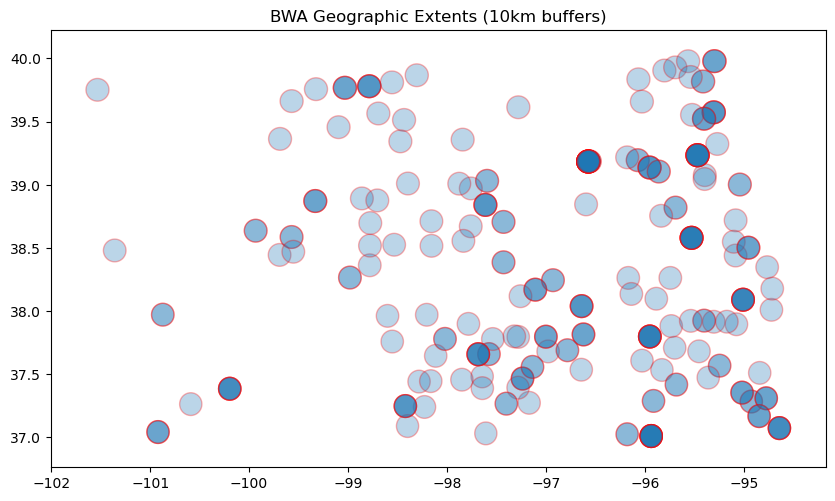

In [145]:
from matplotlib import pyplot as plt


print("Buffers created!")

# Quick visualization to check
ax = bwa_gdf.plot(figsize=(10, 8), alpha=0.3, edgecolor='red')
ax.set_title("BWA Geographic Extents (10km buffers)")
plt.show()

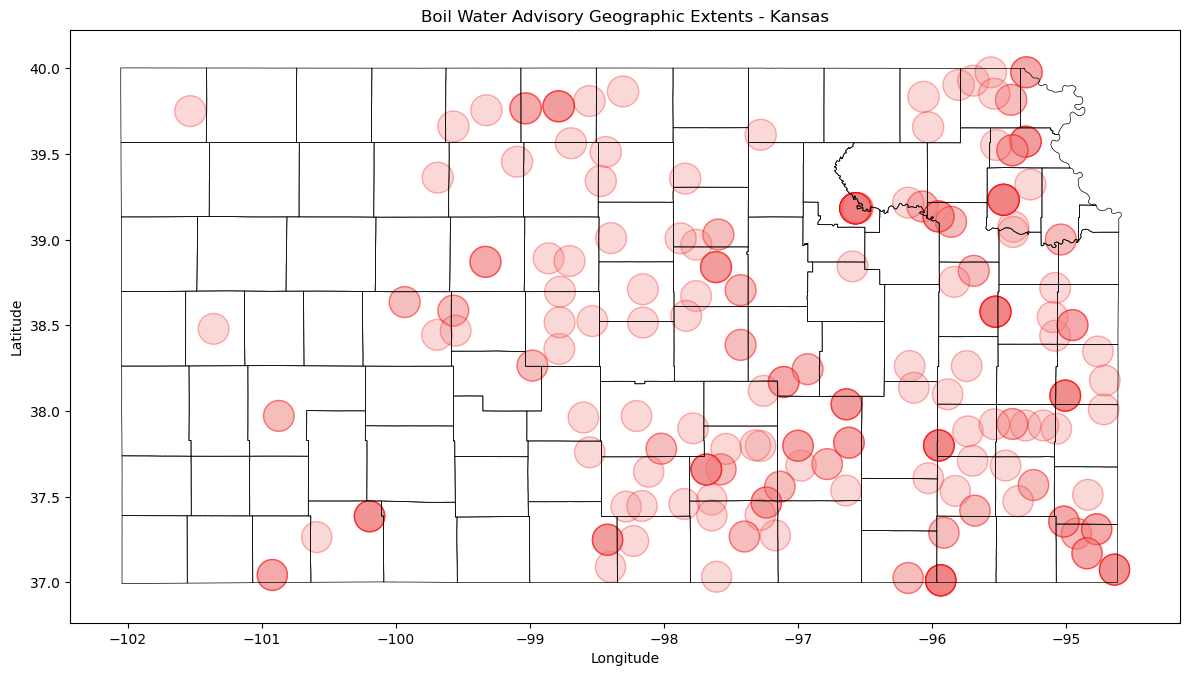

In [146]:
import matplotlib.pyplot as plt

# # Load Kansas counties (if you haven't already)
# counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
# ks_counties = counties[counties['STATEFP'] == '20'].to_crs('EPSG:4326')

# Plot with Kansas basemap
fig, ax = plt.subplots(figsize=(12, 8))

# Kansas counties as basemap
ks_counties.boundary.plot(ax=ax, linewidth=0.5, color='black')

# BWA buffers on top
bwa_gdf.plot(ax=ax, alpha=0.3, edgecolor='red', facecolor='lightcoral')

ax.set_title("Boil Water Advisory Geographic Extents - Kansas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

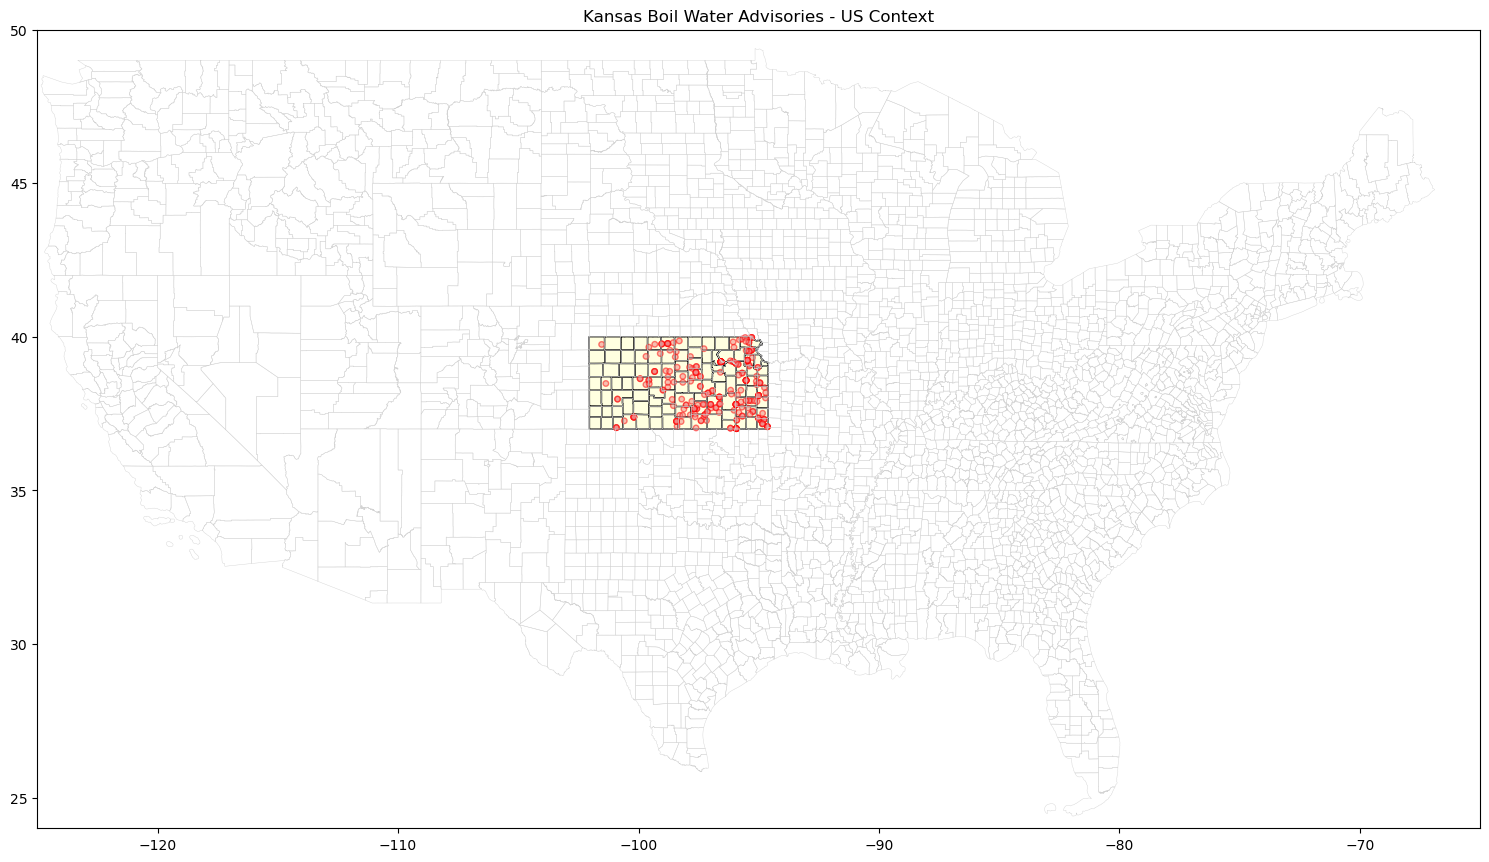

In [147]:

# Loading all US counties
us_counties = gpd.read_file('tl_2024_us_county/tl_2024_us_county.shp')
us_counties = us_counties.to_crs('EPSG:4326')

# Plot
fig, ax = plt.subplots(figsize=(15, 10))

# US counties as basemap (light gray)
us_counties.boundary.plot(ax=ax, linewidth=0.3, color='lightgray')

# Kansas counties highlighted
ks_counties = us_counties[us_counties['STATEFP'] == '20']
ks_counties.plot(ax=ax, color='lightyellow', edgecolor='black', linewidth=1)

# BWA buffers on top
bwa_gdf.plot(ax=ax, alpha=0.5, edgecolor='red', facecolor='lightcoral')

ax.set_title("Kansas Boil Water Advisories - US Context")
ax.set_xlim(-125, -65)  # Continental US
ax.set_ylim(24, 50)
plt.tight_layout()
plt.show()